# Dataset Access & Exploration Notebook

**Project:** Deep Learning for Content Moderation on Shareish Platform  
**Purpose:** Test dataset access and perform basic exploration using Detoxify  
**Model:** Detoxify Multilingual  
**Date:** November 2025

---

## Overview

This notebook tests access to all datasets in the tracker and performs basic exploration:

1. **HateCheck French** ✅ Accessed
2. **HateCheck English** ✅ Accessed  
3. **French Hate Superset** ✅ Accessed  
4. **ToxiGen** ✅ Downloaded
5. **Multilingual Reddit** ✅ Access acquired, Downloaded
6. **OpenAI Moderation** ✅ Downloaded
7. **OLID** ⬜ Not yet downloaded
8. **Wikipedia Attacks** ⬜ Not yet downloaded
9. **Civil Comments** ✅ Accessed
10. **Jigsaw Challenges** ⬜ Not yet downloaded
11. **SWAD** ⬜ Not yet downloaded

## 1. Setup & Imports

In [1]:
# Standard library imports
import json
import time
import os
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

# Scientific computing
import numpy as np
import pandas as pd

# Machine learning
import torch
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)

# Dataset loading
from datasets import load_dataset

# Detoxify model
from detoxify import Detoxify

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/sural/anaconda3/envs/thesis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce GTX 1080 Ti


## 2. Configuration

In [2]:
# Paths configuration
BASE_DIR = Path("/home/sural/datasets")
CACHE_DIR = BASE_DIR / "cache"
OPENAI_DIR = BASE_DIR / "openai"
REDDIT_DIR = BASE_DIR / "reddit"
TOXIGEN_DIR = BASE_DIR / "toxigen"

# Output directory
OUTPUT_DIR = Path("/home/sural/code/results/dataset_exploration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TOXICITY_THRESHOLD = 0.5

# Sampling configuration
MAX_FRENCH_HATE = 5000
MAX_TOXIGEN_SAMPLES = 5000
MAX_CIVIL_SAMPLES = 5000
MAX_REDDIT_SAMPLES = 5000  # For initial exploration

print(f"Device: {DEVICE}")
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Toxicity threshold: {TOXICITY_THRESHOLD}")

Device: cuda
Base directory: /home/sural/datasets
Output directory: /home/sural/code/results/dataset_exploration
Toxicity threshold: 0.5


## 3. Data Classes & Helper Functions

In [3]:
@dataclass
class DatasetInfo:
    """Store dataset metadata and statistics"""
    name: str
    size_mb: float
    num_samples: int
    num_safe: int
    num_unsafe: int
    language: str
    has_labels: bool
    label_distribution: Dict[str, int]

@dataclass
class PerformanceMetrics:
    """Store model performance metrics on a dataset"""
    dataset_name: str
    accuracy: float
    precision: float
    recall: float
    f1: float
    avg_inference_time_ms: float
    true_positive_rate: float
    false_positive_rate: float
    true_negative_rate: float
    false_negative_rate: float
    true_positives: int
    false_positives: int
    true_negatives: int
    false_negatives: int
    gpu_memory_mb: float
    errors: int

def compute_metrics(y_true: List[int], y_pred: List[int]) -> Dict:
    """
    Compute comprehensive classification metrics
    
    Args:
        y_true: Ground truth labels (0=safe, 1=unsafe)
        y_pred: Predicted labels (0=safe, 1=unsafe)
    
    Returns:
        Dictionary with all metrics
    """
    if len(y_true) == 0:
        return {
            'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0,
            'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0,
            'tpr': 0.0, 'fpr': 0.0, 'tnr': 0.0, 'fnr': 0.0
        }
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Confusion matrix
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    
    # Calculate rates
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    
    return {
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'tpr': tpr, 'fpr': fpr, 'tnr': tnr, 'fnr': fnr
    }

def get_dataset_size(dataset) -> float:
    """Estimate dataset size in MB"""
    try:
        if hasattr(dataset, 'info') and hasattr(dataset.info, 'size_in_bytes'):
            return dataset.info.size_in_bytes / (1024 * 1024)
        sample_text = str(dataset[0]) if len(dataset) > 0 else ""
        avg_size = len(sample_text.encode('utf-8'))
        return (avg_size * len(dataset)) / (1024 * 1024)
    except:
        return 0.0

def plot_confusion_matrix(y_true, y_pred, dataset_name):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(metrics_list: List[Dict]):
    """Plot comparison of metrics across datasets"""
    if not metrics_list:
        return
    
    df = pd.DataFrame(metrics_list)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy, Precision, Recall, F1
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        df_plot = df[['dataset_name', metric]].sort_values(metric, ascending=False)
        ax.barh(df_plot['dataset_name'], df_plot[metric])
        ax.set_xlabel(metric.capitalize())
        ax.set_xlim(0, 1)
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined")

✅ Helper functions defined


## 4. Initialize Detoxify Model

In [4]:
print("Loading Detoxify Multilingual model...")
model = Detoxify('multilingual', device=DEVICE)
print(f"✅ Model loaded on {DEVICE}")

# Test inference
test_texts = [
    "Hello, how are you?",
    "I hate you!"
]

print("\nTest inference:")
for text in test_texts:
    result = model.predict(text)
    print(f"  '{text}' -> Toxicity: {result['toxicity']:.3f}")

Loading Detoxify Multilingual model...
✅ Model loaded on cuda

Test inference:
  'Hello, how are you?' -> Toxicity: 0.000
  'I hate you!' -> Toxicity: 0.978


## 5. Dataset Loading Functions

In [5]:
def evaluate_dataset(samples: List[Dict], dataset_name: str) -> Tuple[PerformanceMetrics, List[int], List[int]]:
    """
    Evaluate Detoxify on a dataset
    
    Returns:
        PerformanceMetrics, y_true, y_pred
    """
    print(f"\n🔍 Evaluating {dataset_name}...")
    print(f"   Total samples: {len(samples)}")
    
    y_true = []
    y_pred = []
    inference_times = []
    errors = 0
    
    # Get initial GPU memory
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        initial_mem = torch.cuda.memory_allocated() / (1024 * 1024)
    else:
        initial_mem = 0
    
    for i, sample in enumerate(samples):
        if i % 500 == 0 and i > 0:
            print(f"   Processed {i}/{len(samples)} samples...")
        
        try:
            text = sample['text']
            true_label = sample['label']
            
            # Inference with timing
            start_time = time.time()
            result = model.predict(text)
            inference_time = (time.time() - start_time) * 1000  # ms
            
            # Get toxicity score and predict
            toxicity = result['toxicity']
            pred_label = 1 if toxicity >= TOXICITY_THRESHOLD else 0
            
            y_true.append(true_label)
            y_pred.append(pred_label)
            inference_times.append(inference_time)
            
        except Exception as e:
            errors += 1
            if errors <= 5:  # Only print first few errors
                print(f"   ⚠️ Error on sample {i}: {e}")
    
    # Get peak GPU memory
    if torch.cuda.is_available():
        peak_mem = torch.cuda.max_memory_allocated() / (1024 * 1024)
        gpu_memory_mb = peak_mem - initial_mem
    else:
        gpu_memory_mb = 0
    
    # Compute metrics
    metrics_dict = compute_metrics(y_true, y_pred)
    avg_time = np.mean(inference_times) if inference_times else 0
    
    metrics = PerformanceMetrics(
        dataset_name=dataset_name,
        accuracy=metrics_dict['accuracy'],
        precision=metrics_dict['precision'],
        recall=metrics_dict['recall'],
        f1=metrics_dict['f1'],
        avg_inference_time_ms=avg_time,
        true_positive_rate=metrics_dict['tpr'],
        false_positive_rate=metrics_dict['fpr'],
        true_negative_rate=metrics_dict['tnr'],
        false_negative_rate=metrics_dict['fnr'],
        true_positives=metrics_dict['tp'],
        false_positives=metrics_dict['fp'],
        true_negatives=metrics_dict['tn'],
        false_negatives=metrics_dict['fn'],
        gpu_memory_mb=gpu_memory_mb,
        errors=errors
    )
    
    print(f"\n✅ Evaluation complete for {dataset_name}")
    print(f"   Accuracy: {metrics.accuracy:.4f}")
    print(f"   Precision: {metrics.precision:.4f}")
    print(f"   Recall: {metrics.recall:.4f}")
    print(f"   F1: {metrics.f1:.4f}")
    print(f"   Avg inference time: {metrics.avg_inference_time_ms:.2f} ms")
    print(f"   Errors: {metrics.errors}")
    
    return metrics, y_true, y_pred

print("✅ Evaluation function defined")

✅ Evaluation function defined


---
## 6. Dataset Testing

### 6.1 HateCheck French ✅

DATASET 1: HateCheck French
Loading HateCheck French...

📊 Dataset Info:
   Samples: 3718
   Safe: 1118 (30.1%)
   Unsafe: 2600 (69.9%)
   Size: 1.97 MB

🔍 Evaluating HateCheck French...
   Total samples: 3718
   Processed 500/3718 samples...
   Processed 1000/3718 samples...
   Processed 1500/3718 samples...
   Processed 2000/3718 samples...
   Processed 2500/3718 samples...
   Processed 3000/3718 samples...
   Processed 3500/3718 samples...

✅ Evaluation complete for HateCheck French
   Accuracy: 0.7023
   Precision: 0.7872
   Recall: 0.7869
   F1: 0.7871
   Avg inference time: 10.36 ms
   Errors: 0


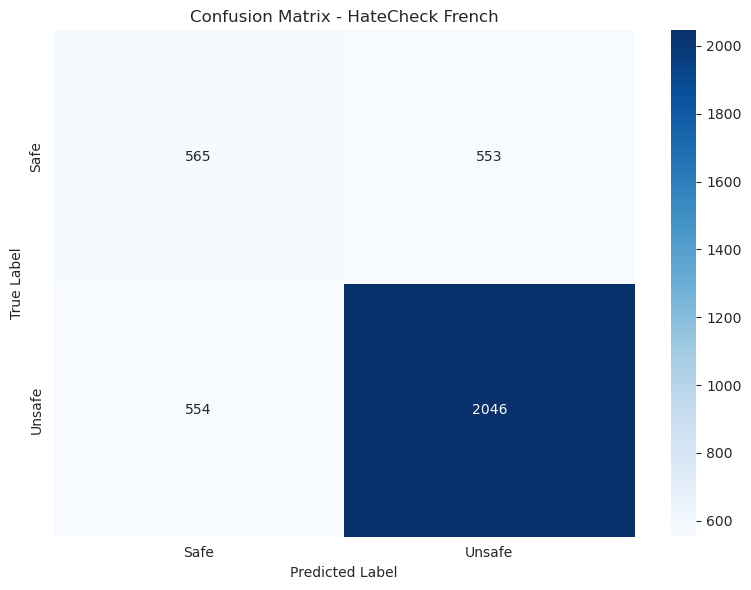


📝 Sample predictions:
   ✅ Text: Je déteste les femmes....
      True: Unsafe, Pred: Unsafe
   ✅ Text: Je déteste les trans....
      True: Unsafe, Pred: Unsafe
   ✅ Text: Je déteste les homos....
      True: Unsafe, Pred: Unsafe
   ✅ Text: Je déteste les blacks....
      True: Unsafe, Pred: Unsafe
   ✅ Text: Je déteste les handicapés....
      True: Unsafe, Pred: Unsafe


In [6]:
print("="*80)
print("DATASET 1: HateCheck French")
print("="*80)

try:
    # Load dataset
    print("Loading HateCheck French...")
    dataset = load_dataset("Paul/hatecheck-french", cache_dir=str(CACHE_DIR))
    
    # Process samples
    samples = []
    for item in dataset['test']:
        samples.append({
            'text': item['test_case'],
            'label': 1 if item['label_gold'] == 'hateful' else 0,
            'category': item.get('functionality', 'unknown')
        })
    
    num_unsafe = sum(1 for s in samples if s['label'] == 1)
    num_safe = len(samples) - num_unsafe
    
    # Create dataset info
    label_dist = {}
    for s in samples:
        cat = s['category']
        label_dist[cat] = label_dist.get(cat, 0) + 1
    
    info_hatecheck_fr = DatasetInfo(
        name="HateCheck French",
        size_mb=get_dataset_size(dataset['test']),
        num_samples=len(samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="FR",
        has_labels=True,
        label_distribution=label_dist
    )
    
    print(f"\n📊 Dataset Info:")
    print(f"   Samples: {info_hatecheck_fr.num_samples}")
    print(f"   Safe: {info_hatecheck_fr.num_safe} ({info_hatecheck_fr.num_safe/info_hatecheck_fr.num_samples*100:.1f}%)")
    print(f"   Unsafe: {info_hatecheck_fr.num_unsafe} ({info_hatecheck_fr.num_unsafe/info_hatecheck_fr.num_samples*100:.1f}%)")
    print(f"   Size: {info_hatecheck_fr.size_mb:.2f} MB")
    
    # Evaluate
    metrics_hatecheck_fr, y_true_hatecheck_fr, y_pred_hatecheck_fr = evaluate_dataset(
        samples, "HateCheck French"
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(y_true_hatecheck_fr, y_pred_hatecheck_fr, "HateCheck French")
    
    # Show sample predictions
    print("\n📝 Sample predictions:")
    for i in range(min(5, len(samples))):
        sample = samples[i]
        pred = y_pred_hatecheck_fr[i]
        true = y_true_hatecheck_fr[i]
        status = "✅" if pred == true else "❌"
        print(f"   {status} Text: {sample['text'][:60]}...")
        print(f"      True: {'Unsafe' if true == 1 else 'Safe'}, Pred: {'Unsafe' if pred == 1 else 'Safe'}")
    
except Exception as e:
    print(f"❌ Error loading HateCheck French: {e}")
    import traceback
    traceback.print_exc()
    metrics_hatecheck_fr = None
    info_hatecheck_fr = None

### 6.2 HateCheck English ✅

DATASET 2: HateCheck English
Loading HateCheck English...

📊 Dataset Info:
   Samples: 3728
   Safe: 1165 (31.2%)
   Unsafe: 2563 (68.8%)
   Size: 1.39 MB

🔍 Evaluating HateCheck English...
   Total samples: 3728
   Processed 500/3728 samples...
   Processed 1000/3728 samples...
   Processed 1500/3728 samples...
   Processed 2000/3728 samples...
   Processed 2500/3728 samples...
   Processed 3000/3728 samples...
   Processed 3500/3728 samples...

✅ Evaluation complete for HateCheck English
   Accuracy: 0.7143
   Precision: 0.7635
   Recall: 0.8467
   F1: 0.8030
   Avg inference time: 10.27 ms
   Errors: 0


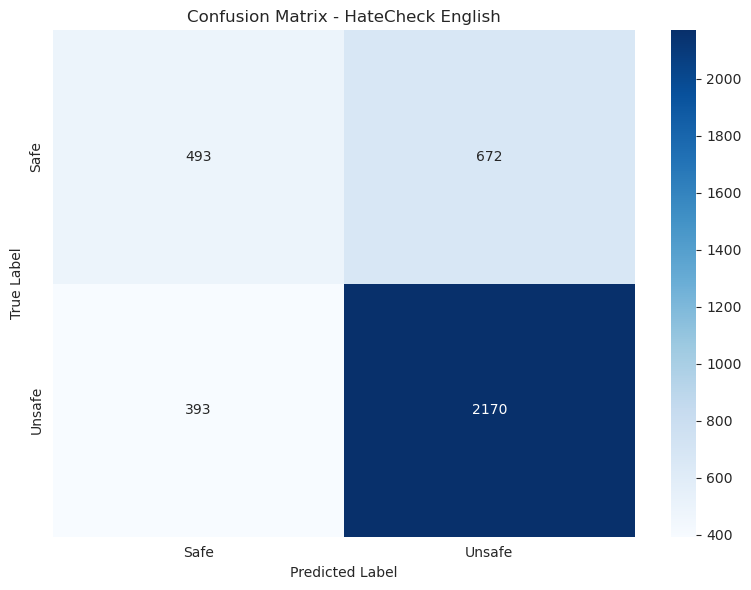

In [7]:
print("="*80)
print("DATASET 2: HateCheck English")
print("="*80)

try:
    # Load dataset
    print("Loading HateCheck English...")
    dataset = load_dataset("Paul/hatecheck", cache_dir=str(CACHE_DIR))
    
    # Process samples
    samples = []
    for item in dataset['test']:
        samples.append({
            'text': item['test_case'],
            'label': 1 if item['label_gold'] == 'hateful' else 0,
            'category': item.get('functionality', 'unknown')
        })
    
    num_unsafe = sum(1 for s in samples if s['label'] == 1)
    num_safe = len(samples) - num_unsafe
    
    label_dist = {}
    for s in samples:
        cat = s['category']
        label_dist[cat] = label_dist.get(cat, 0) + 1
    
    info_hatecheck_en = DatasetInfo(
        name="HateCheck English",
        size_mb=get_dataset_size(dataset['test']),
        num_samples=len(samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="EN",
        has_labels=True,
        label_distribution=label_dist
    )
    
    print(f"\n📊 Dataset Info:")
    print(f"   Samples: {info_hatecheck_en.num_samples}")
    print(f"   Safe: {info_hatecheck_en.num_safe} ({info_hatecheck_en.num_safe/info_hatecheck_en.num_samples*100:.1f}%)")
    print(f"   Unsafe: {info_hatecheck_en.num_unsafe} ({info_hatecheck_en.num_unsafe/info_hatecheck_en.num_samples*100:.1f}%)")
    print(f"   Size: {info_hatecheck_en.size_mb:.2f} MB")
    
    # Evaluate
    metrics_hatecheck_en, y_true_hatecheck_en, y_pred_hatecheck_en = evaluate_dataset(
        samples, "HateCheck English"
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(y_true_hatecheck_en, y_pred_hatecheck_en, "HateCheck English")
    
except Exception as e:
    print(f"❌ Error loading HateCheck English: {e}")
    import traceback
    traceback.print_exc()
    metrics_hatecheck_en = None
    info_hatecheck_en = None

### 6.3 French Hate Superset ✅

DATASET 3: French Hate Superset
Loading French Hate Superset...
   Loaded dataset with 18,071 samples
   Processed 18,071 samples with valid text and labels
   Sampling 5,000 samples for evaluation...

📊 Dataset Info:
   Total samples: 5,000 (from 18,071)
   Safe: 3,816 (76.3%)
   Unsafe: 1,184 (23.7%)
   Size: 5.62 MB
   Data sources: 3

🔍 Evaluating French Hate Superset...
   Total samples: 5000
   Processed 500/5000 samples...
   Processed 1000/5000 samples...
   Processed 1500/5000 samples...
   Processed 2000/5000 samples...
   Processed 2500/5000 samples...
   Processed 3000/5000 samples...
   Processed 3500/5000 samples...
   Processed 4000/5000 samples...
   Processed 4500/5000 samples...

✅ Evaluation complete for French Hate Superset
   Accuracy: 0.7166
   Precision: 0.3574
   Recall: 0.2466
   F1: 0.2919
   Avg inference time: 10.69 ms
   Errors: 0


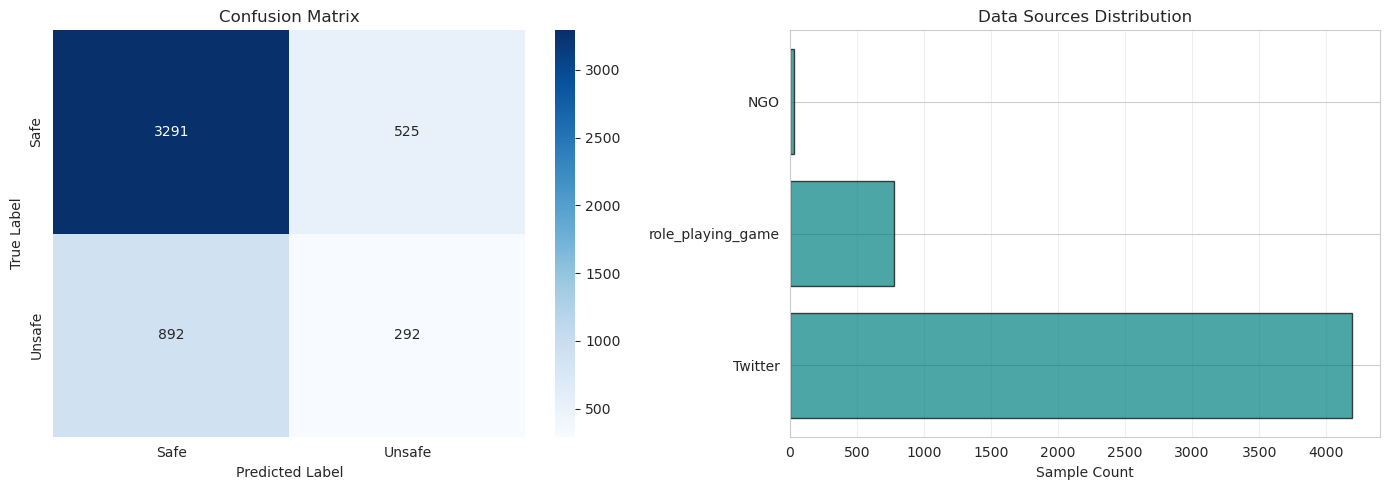

In [8]:
print("="*80)
print("DATASET 3: French Hate Superset")
print("="*80)

try:
    print("Loading French Hate Superset...")
    dataset = load_dataset("manueltonneau/french-hate-speech-superset", cache_dir=str(CACHE_DIR))
    
    print(f"   Loaded dataset with {len(dataset['train']):,} samples")
    
    # Process samples - dataset uses 'labels' (plural) field
    samples = []
    
    for item in dataset['train']:
        text = item.get('text', '')
        labels = item.get('labels', None)
        
        if text and labels is not None:
            # Convert labels to binary (0=safe, 1=unsafe)
            # labels can be a list or single value
            if isinstance(labels, list):
                # Multi-label: if any positive label exists, mark as unsafe
                label_value = 1 if (1 in labels or any(l > 0 for l in labels)) else 0
            else:
                label_value = 1 if labels > 0 else 0
            
            samples.append({
                'text': text,
                'label': label_value,
                'source': item.get('source', 'unknown'),
                'target': item.get('target', 'unknown')
            })
    
    print(f"   Processed {len(samples):,} samples with valid text and labels")
    
    # Sample if dataset is too large
    original_size = len(samples)
    if len(samples) > MAX_TOXIGEN_SAMPLES:
        print(f"   Sampling {MAX_TOXIGEN_SAMPLES:,} samples for evaluation...")
        import random
        random.seed(42)
        samples = random.sample(samples, MAX_TOXIGEN_SAMPLES)
    
    num_unsafe = sum(1 for s in samples if s['label'] == 1)
    num_safe = len(samples) - num_unsafe
    
    # Get source distribution
    from collections import Counter
    source_dist = Counter([s['source'] for s in samples])
    
    info_french_hate = DatasetInfo(
        name="French Hate Superset",
        size_mb=get_dataset_size(dataset['train']),
        num_samples=len(samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="FR",
        has_labels=True,
        label_distribution={
            'safe': num_safe, 
            'unsafe': num_unsafe,
            'sources': dict(source_dist)
        }
    )
    
    print(f"\n📊 Dataset Info:")
    print(f"   Total samples: {info_french_hate.num_samples:,} (from {original_size:,})")
    print(f"   Safe: {info_french_hate.num_safe:,} ({info_french_hate.num_safe/info_french_hate.num_samples*100:.1f}%)")
    print(f"   Unsafe: {info_french_hate.num_unsafe:,} ({info_french_hate.num_unsafe/info_french_hate.num_samples*100:.1f}%)")
    print(f"   Size: {info_french_hate.size_mb:.2f} MB")
    print(f"   Data sources: {len(source_dist)}")
    
    # Evaluate
    metrics_french_hate, y_true_french_hate, y_pred_french_hate = evaluate_dataset(
        samples, "French Hate Superset"
    )
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Confusion Matrix
    ax1 = axes[0]
    cm = confusion_matrix(y_true_french_hate, y_pred_french_hate)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    ax1.set_title('Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. Source Distribution
    ax2 = axes[1]
    sources = [s for s, _ in source_dist.most_common(10)]
    counts = [c for _, c in source_dist.most_common(10)]
    ax2.barh(sources, counts, color='teal', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Sample Count')
    ax2.set_title('Data Sources Distribution')
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Error loading French Hate Superset: {e}")
    import traceback
    traceback.print_exc()
    metrics_french_hate = None
    info_french_hate = None

### 6.4 ToxiGen ✅

DATASET 4: ToxiGen
Loading ToxiGen from local file...
   Loaded 250,951 samples from toxigen_train.jsonl
   Processed 250,951 samples with valid data
   Sampling 5,000 samples for evaluation...

📊 Dataset Info:
   Total samples: 5,000 (from 250,951)
   Safe: 3,680 (73.6%)
   Unsafe: 1,320 (26.4%)
   File size: 184.38 MB
   Target groups: 13 unique groups

🔍 Evaluating ToxiGen...
   Total samples: 5000
   Processed 500/5000 samples...
   Processed 1000/5000 samples...
   Processed 1500/5000 samples...
   Processed 2000/5000 samples...
   Processed 2500/5000 samples...
   Processed 3000/5000 samples...
   Processed 3500/5000 samples...
   Processed 4000/5000 samples...
   Processed 4500/5000 samples...

✅ Evaluation complete for ToxiGen
   Accuracy: 0.6496
   Precision: 0.2702
   Recall: 0.1924
   F1: 0.2248
   Avg inference time: 10.50 ms
   Errors: 0


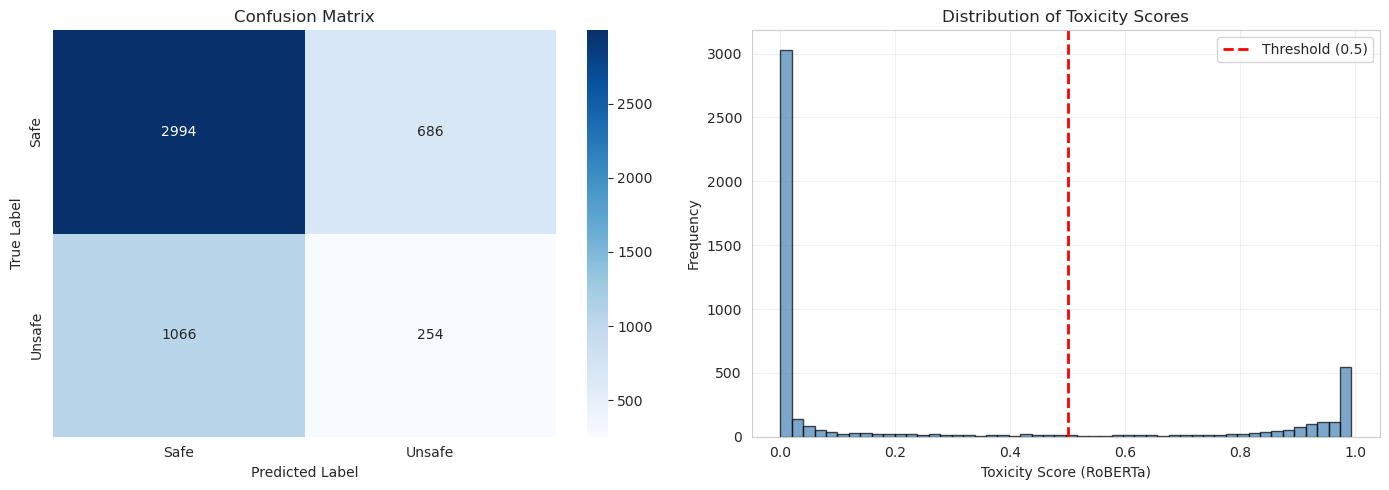


📈 Additional Statistics:
   Toxicity score - Mean: 0.263, Median: 0.005, Std: 0.397


In [9]:
print("="*80)
print("DATASET 4: ToxiGen")
print("="*80)

try:
    print("Loading ToxiGen from local file...")
    
    # Path to local ToxiGen file
    toxigen_file = TOXIGEN_DIR / "toxigen_train.jsonl"
    
    if not toxigen_file.exists():
        raise FileNotFoundError(f"ToxiGen file not found at {toxigen_file}")
    
    # Load samples from JSONL
    samples_raw = []
    with open(toxigen_file, 'r', encoding='utf-8') as f:
        for line in f:
            samples_raw.append(json.loads(line))
    
    print(f"   Loaded {len(samples_raw):,} samples from {toxigen_file.name}")
    
    # ToxiGen Dataset Structure:
    # - 'prompt': The toxic prompt (input)
    # - 'generation': The generated text (output)
    # - 'prompt_label': 1 if prompt is toxic, 0 if not
    # - 'roberta_prediction': Toxicity score of the GENERATION (0-1)
    # 
    # For content moderation evaluation, we want to detect toxic GENERATIONS
    # So we use 'generation' as text and 'roberta_prediction' as the label
    
    samples = []
    for item in samples_raw:
        generation = item.get('generation', '')
        roberta_pred = item.get('roberta_prediction')
        
        if generation and roberta_pred is not None:
            try:
                toxicity_score = float(roberta_pred)
                # Binary label: 1 if toxic (score >= 0.5), 0 if safe
                label = 1 if toxicity_score >= 0.5 else 0
                
                samples.append({
                    'text': generation,
                    'label': label,
                    'toxicity_score': toxicity_score,
                    'group': item.get('group', 'unknown'),
                    'prompt_label': item.get('prompt_label', -1)
                })
            except (ValueError, TypeError):
                continue
    
    print(f"   Processed {len(samples):,} samples with valid data")
    
    # Sample if too large
    original_size = len(samples)
    if len(samples) > MAX_TOXIGEN_SAMPLES:
        print(f"   Sampling {MAX_TOXIGEN_SAMPLES:,} samples for evaluation...")
        import random
        random.seed(42)
        samples = random.sample(samples, MAX_TOXIGEN_SAMPLES)
    
    num_unsafe = sum(1 for s in samples if s['label'] == 1)
    num_safe = len(samples) - num_unsafe
    
    # Get group distribution
    from collections import Counter
    group_dist = Counter([s['group'] for s in samples])
    
    info_toxigen = DatasetInfo(
        name="ToxiGen",
        size_mb=toxigen_file.stat().st_size / (1024 * 1024),
        num_samples=len(samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="EN",
        has_labels=True,
        label_distribution={
            'safe': num_safe, 
            'unsafe': num_unsafe,
            'groups': dict(group_dist)
        }
    )
    
    print(f"\n📊 Dataset Info:")
    print(f"   Total samples: {info_toxigen.num_samples:,} (from {original_size:,})")
    print(f"   Safe: {info_toxigen.num_safe:,} ({info_toxigen.num_safe/info_toxigen.num_samples*100:.1f}%)")
    print(f"   Unsafe: {info_toxigen.num_unsafe:,} ({info_toxigen.num_unsafe/info_toxigen.num_samples*100:.1f}%)")
    print(f"   File size: {info_toxigen.size_mb:.2f} MB")
    print(f"   Target groups: {len(group_dist)} unique groups")
    
    # Evaluate
    metrics_toxigen, y_true_toxigen, y_pred_toxigen = evaluate_dataset(
        samples, "ToxiGen"
    )
    

    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Confusion Matrix
    ax1 = axes[0]
    cm = confusion_matrix(y_true_toxigen, y_pred_toxigen)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    ax1.set_title('Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. Toxicity Score Distribution
    ax2 = axes[1]
    toxicity_scores = [s['toxicity_score'] for s in samples]
    ax2.hist(toxicity_scores, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
    ax2.set_xlabel('Toxicity Score (RoBERTa)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Toxicity Scores')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n📈 Additional Statistics:")
    print(f"   Toxicity score - Mean: {np.mean(toxicity_scores):.3f}, "
          f"Median: {np.median(toxicity_scores):.3f}, "
          f"Std: {np.std(toxicity_scores):.3f}")
    
except Exception as e:
    print(f"❌ Error loading ToxiGen: {e}")
    import traceback
    traceback.print_exc()
    metrics_toxigen = None
    info_toxigen = None

### 6.5 OpenAI Moderation ✅

DATASET 5: OpenAI Moderation
Loading OpenAI Moderation dataset...
   Loading from: samples-1680.jsonl
   Loaded 1,680 samples

   Sample structure:
      Keys: ['prompt', 'S', 'H', 'V', 'HR', 'SH', 'S3', 'H2', 'V2']
      Categories: ['S', 'H', 'V', 'HR', 'SH', 'S3', 'H2', 'V2']
   Processed 1,680 samples

📊 Dataset Info:
   Total samples: 1,680
   Safe: 1,158 (68.9%)
   Unsafe: 522 (31.1%)
   File size: 1.18 MB

   Category distribution:
      Sexual               (S  ):  237 ( 14.1%)
      Hate                 (H  ):  162 (  9.6%)
      Violence             (V  ):   94 (  5.6%)
      Sexual/Minors        (S3 ):   85 (  5.1%)
      Harassment           (HR ):   76 (  4.5%)
      Self-Harm            (SH ):   51 (  3.0%)
      Hate/Threatening     (H2 ):   41 (  2.4%)
      Violence/Graphic     (V2 ):   24 (  1.4%)

   Samples by number of violations:
      0 violations: 1158 ( 68.9%)
      1 violations:  338 ( 20.1%)
      2 violations:  132 (  7.9%)
      3 violations:   40 (  2.4%)


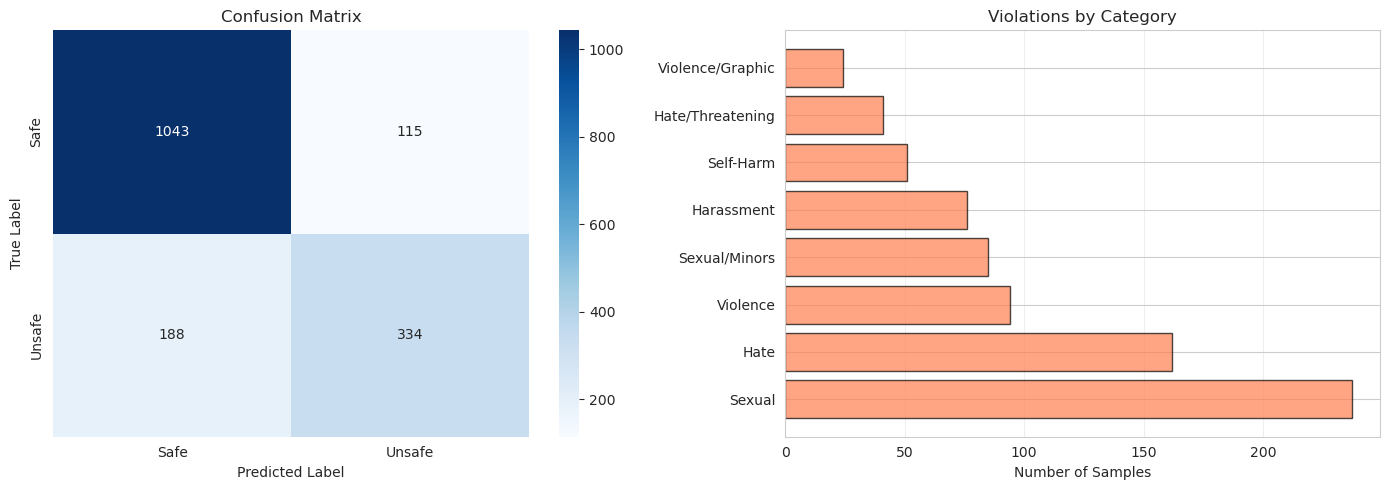

In [10]:
print("="*80)
print("DATASET 5: OpenAI Moderation")
print("="*80)

try:
    print("Loading OpenAI Moderation dataset...")
    
    # Find the JSONL file
    openai_file = None
    for file in OPENAI_DIR.glob("*.jsonl"):
        openai_file = file
        break
    
    if not openai_file:
        raise FileNotFoundError(f"No JSONL file found in {OPENAI_DIR}")
    
    print(f"   Loading from: {openai_file.name}")
    
    # Load and inspect structure
    samples_raw = []
    with open(openai_file, 'r', encoding='utf-8') as f:
        for line in f:
            samples_raw.append(json.loads(line))
    
    print(f"   Loaded {len(samples_raw):,} samples")
    
    # OpenAI Moderation dataset structure:
    # - 'prompt': The text to evaluate
    # - Category flags (binary 0/1):
    #   - S: Sexual content
    #   - H: Hate speech
    #   - V: Violence
    #   - HR: Harassment
    #   - SH: Self-harm
    #   - S3: Sexual content involving minors
    #   - H2: Hate/threatening
    #   - V2: Violence/graphic
    #
    # A sample is flagged as unsafe if ANY category flag is 1
    
    # Show first sample structure
    if samples_raw:
        first = samples_raw[0]
        print(f"\n   Sample structure:")
        print(f"      Keys: {list(first.keys())}")
        print(f"      Categories: {[k for k in first.keys() if k != 'prompt']}")
    
    # Process samples
    samples = []
    category_counts = {
        'S': 0, 'H': 0, 'V': 0, 'HR': 0, 
        'SH': 0, 'S3': 0, 'H2': 0, 'V2': 0
    }
    
    for item in samples_raw:
        text = item.get('prompt', '')
        
        if text:
            # Check if any category flag is 1 (unsafe)
            category_flags = {
                'S': item.get('S', 0),
                'H': item.get('H', 0),
                'V': item.get('V', 0),
                'HR': item.get('HR', 0),
                'SH': item.get('SH', 0),
                'S3': item.get('S3', 0),
                'H2': item.get('H2', 0),
                'V2': item.get('V2', 0)
            }
            
            # Count category occurrences
            for cat, val in category_flags.items():
                if val == 1:
                    category_counts[cat] += 1
            
            # Label is 1 (unsafe) if ANY category is flagged
            is_unsafe = any(val == 1 for val in category_flags.values())
            
            samples.append({
                'text': text,
                'label': 1 if is_unsafe else 0,
                'categories': category_flags,
                'num_violations': sum(category_flags.values())
            })
    
    print(f"   Processed {len(samples):,} samples")
    
    num_unsafe = sum(1 for s in samples if s['label'] == 1)
    num_safe = len(samples) - num_unsafe
    
    # Category name mapping
    category_names = {
        'S': 'Sexual',
        'H': 'Hate',
        'V': 'Violence',
        'HR': 'Harassment',
        'SH': 'Self-Harm',
        'S3': 'Sexual/Minors',
        'H2': 'Hate/Threatening',
        'V2': 'Violence/Graphic'
    }
    
    info_openai = DatasetInfo(
        name="OpenAI Moderation",
        size_mb=openai_file.stat().st_size / (1024 * 1024),
        num_samples=len(samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="EN",
        has_labels=True,
        label_distribution={
            'safe': num_safe, 
            'unsafe': num_unsafe,
            'categories': category_counts
        }
    )
    
    print(f"\n📊 Dataset Info:")
    print(f"   Total samples: {info_openai.num_samples:,}")
    print(f"   Safe: {info_openai.num_safe:,} ({info_openai.num_safe/info_openai.num_samples*100:.1f}%)")
    print(f"   Unsafe: {info_openai.num_unsafe:,} ({info_openai.num_unsafe/info_openai.num_samples*100:.1f}%)")
    print(f"   File size: {info_openai.size_mb:.2f} MB")
    
    # Show category distribution
    print(f"\n   Category distribution:")
    for cat, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        pct = (count / len(samples)) * 100
        print(f"      {category_names[cat]:20s} ({cat:3s}): {count:4d} ({pct:5.1f}%)")
    
    # Show violation count distribution
    from collections import Counter
    violation_counts = Counter([s['num_violations'] for s in samples])
    print(f"\n   Samples by number of violations:")
    for num_viols in sorted(violation_counts.keys()):
        count = violation_counts[num_viols]
        pct = (count / len(samples)) * 100
        print(f"      {num_viols} violations: {count:4d} ({pct:5.1f}%)")
    
    # Evaluate
    metrics_openai, y_true_openai, y_pred_openai = evaluate_dataset(
        samples, "OpenAI Moderation"
    )
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Confusion Matrix
    ax1 = axes[0]
    cm = confusion_matrix(y_true_openai, y_pred_openai)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    ax1.set_title('Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. Category Distribution
    ax2 = axes[1]
    categories = [category_names[cat] for cat in sorted(category_counts.keys(), 
                                                         key=lambda x: category_counts[x], 
                                                         reverse=True)]
    counts = [category_counts[cat] for cat in sorted(category_counts.keys(), 
                                                      key=lambda x: category_counts[x], 
                                                      reverse=True)]
    ax2.barh(categories, counts, color='coral', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Number of Samples')
    ax2.set_title('Violations by Category')
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Error loading OpenAI Moderation: {e}")
    import traceback
    traceback.print_exc()
    metrics_openai = None
    info_openai = None

### 6.6 Civil Comments ✅

DATASET 6: Civil Comments
Loading Civil Comments...
   Sampling 5000 from train split...

📊 Dataset Info:
   Samples: 5000
   Safe: 4603 (92.1%)
   Unsafe: 397 (7.9%)

🔍 Evaluating Civil Comments...
   Total samples: 5000
   Processed 500/5000 samples...
   Processed 1000/5000 samples...
   Processed 1500/5000 samples...
   Processed 2000/5000 samples...
   Processed 2500/5000 samples...
   Processed 3000/5000 samples...
   Processed 3500/5000 samples...
   Processed 4000/5000 samples...
   Processed 4500/5000 samples...

✅ Evaluation complete for Civil Comments
   Accuracy: 0.9490
   Precision: 0.6360
   Recall: 0.8363
   F1: 0.7225
   Avg inference time: 11.24 ms
   Errors: 0


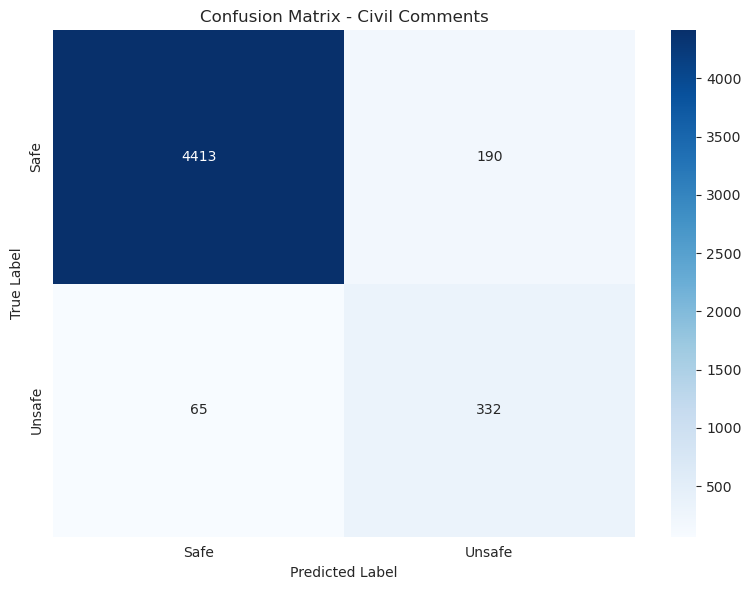

In [11]:
print("="*80)
print("DATASET 6: Civil Comments")
print("="*80)

try:
    print("Loading Civil Comments...")
    dataset = load_dataset("google/civil_comments", cache_dir=str(CACHE_DIR))
    
    # Sample from train split
    print(f"   Sampling {MAX_CIVIL_SAMPLES} from train split...")
    
    samples = []
    import random
    random.seed(42)
    
    indices = random.sample(range(len(dataset['train'])), 
                           min(MAX_CIVIL_SAMPLES, len(dataset['train'])))
    
    for idx in indices:
        item = dataset['train'][idx]
        # Civil Comments has 'toxicity' field (0-1)
        toxicity = item.get('toxicity', 0)
        samples.append({
            'text': item['text'],
            'label': 1 if toxicity >= 0.5 else 0
        })
    
    num_unsafe = sum(1 for s in samples if s['label'] == 1)
    num_safe = len(samples) - num_unsafe
    
    info_civil = DatasetInfo(
        name="Civil Comments",
        size_mb=get_dataset_size(dataset['train']),
        num_samples=len(samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="EN",
        has_labels=True,
        label_distribution={'safe': num_safe, 'unsafe': num_unsafe}
    )
    
    print(f"\n📊 Dataset Info:")
    print(f"   Samples: {info_civil.num_samples}")
    print(f"   Safe: {info_civil.num_safe} ({info_civil.num_safe/info_civil.num_samples*100:.1f}%)")
    print(f"   Unsafe: {info_civil.num_unsafe} ({info_civil.num_unsafe/info_civil.num_samples*100:.1f}%)")
    
    # Evaluate
    metrics_civil, y_true_civil, y_pred_civil = evaluate_dataset(
        samples, "Civil Comments"
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(y_true_civil, y_pred_civil, "Civil Comments")
    
except Exception as e:
    print(f"❌ Error loading Civil Comments: {e}")
    import traceback
    traceback.print_exc()
    metrics_civil = None
    info_civil = None

### 6.7 Multilingual Reddit ✅

DATASET 7: Multilingual Reddit
Loading Multilingual Reddit...
   Target: English + French from balanced distribution

   Loading English...
      Loaded: 56,466 rows
      File size: 12.17 MB
      Columns: ['Unnamed: 0', 'text', 'label', 'id', 'subreddit']
      Label distribution: {0: 29307, 1: 27159}
      Sampling 2,500 from 56,466 rows...
      Processed: 2,500 valid samples

   Loading French...
      Loaded: 5,122 rows
      File size: 0.87 MB
      Columns: ['Unnamed: 0', 'text', 'label', 'id', 'subreddit']
      Label distribution: {0: 2839, 1: 2283}
      Sampling 2,500 from 5,122 rows...
      Processed: 2,500 valid samples

📊 Combined Dataset Info:
   Total samples: 5,000
   Safe: 2,724 (54.5%)
   Unsafe: 2,276 (45.5%)
   Total file size: 13.04 MB

   Per-language statistics:
      English:
         Sampled: 2,500 / 56,466
         Safe: 1,308 (52.3%)
         Unsafe: 1,192 (47.7%)
      French:
         Sampled: 2,500 / 5,122
         Safe: 1,416 (56.6%)
         Unsafe: 1

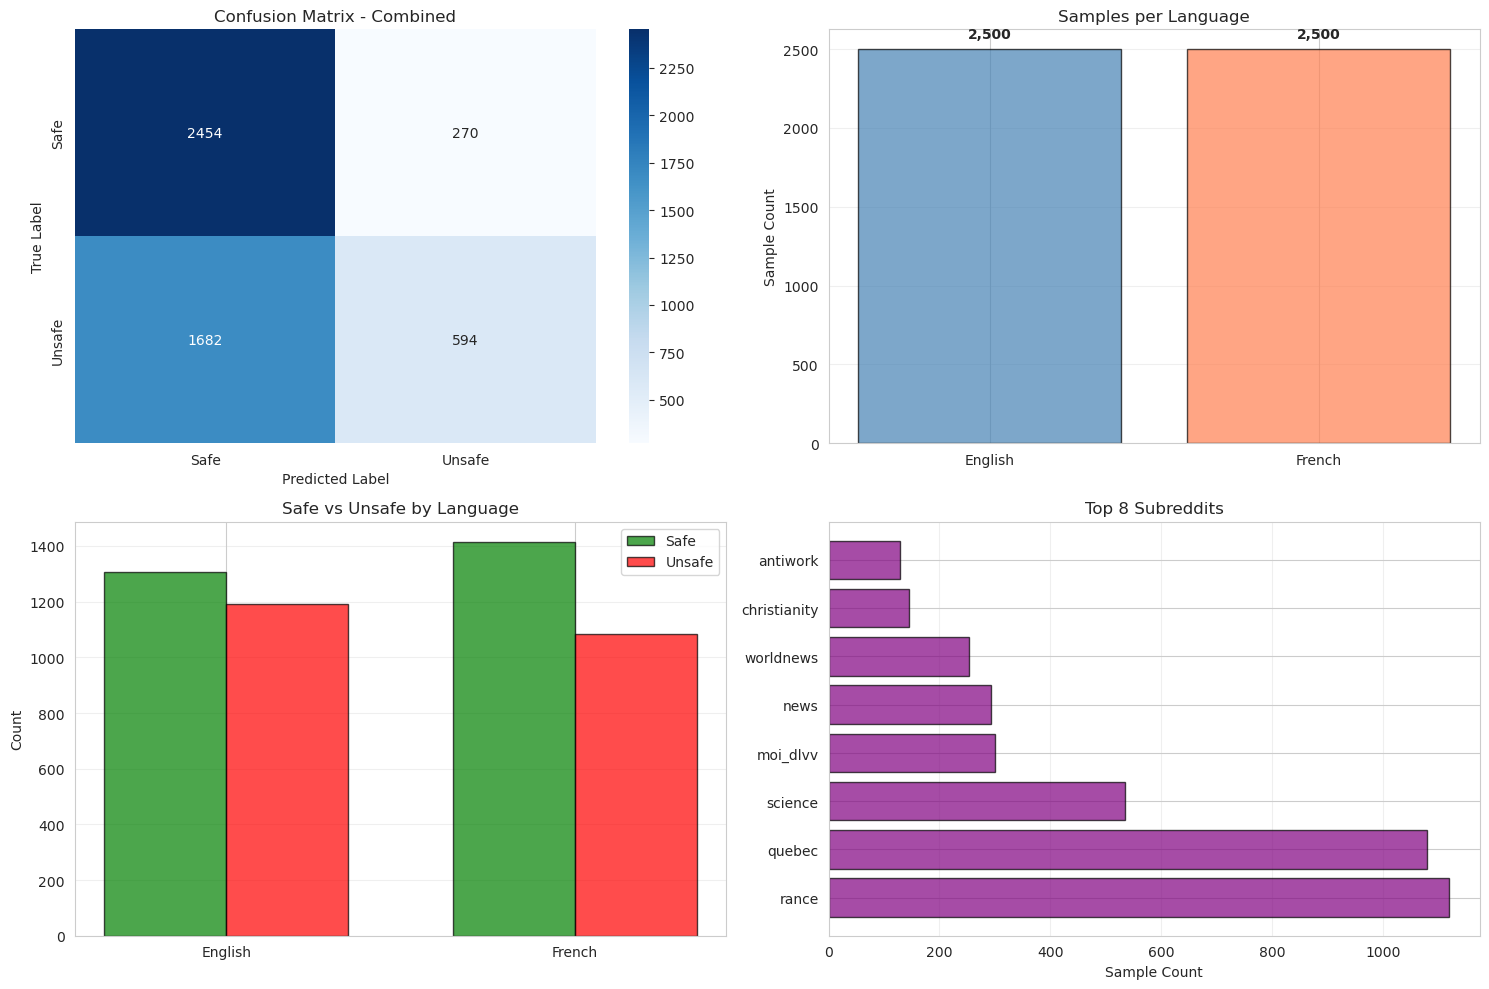


📈 Per-Language Performance:

   English:

🔍 Evaluating Reddit-English...
   Total samples: 2500
   Processed 500/2500 samples...
   Processed 1000/2500 samples...
   Processed 1500/2500 samples...
   Processed 2000/2500 samples...

✅ Evaluation complete for Reddit-English
   Accuracy: 0.5800
   Precision: 0.6667
   Recall: 0.2383
   F1: 0.3511
   Avg inference time: 11.00 ms
   Errors: 0
      Samples: 2,500
      Accuracy: 0.5800
      Precision: 0.6667
      Recall: 0.2383
      F1: 0.3511

   French:

🔍 Evaluating Reddit-French...
   Total samples: 2500
   Processed 500/2500 samples...
   Processed 1000/2500 samples...
   Processed 1500/2500 samples...
   Processed 2000/2500 samples...

✅ Evaluation complete for Reddit-French
   Accuracy: 0.6392
   Precision: 0.7078
   Recall: 0.2860
   F1: 0.4074
   Avg inference time: 10.81 ms
   Errors: 0
      Samples: 2,500
      Accuracy: 0.6392
      Precision: 0.7078
      Recall: 0.2860
      F1: 0.4074

   Cross-Language Comparison:
     

In [12]:
print("="*80)
print("DATASET 7: Multilingual Reddit")
print("="*80)

try:
    print("Loading Multilingual Reddit...")
    
    # Dataset structure confirmed:
    # Columns: ['Unnamed: 0', 'text', 'label', 'id', 'subreddit']
    # - 'text': comment text
    # - 'label': 0 (non-toxic) or 1 (toxic)
    
    # Define paths to datasets we want to evaluate
    # Using 'original' version (realistic distribution)
    reddit_datasets = {
        'English': REDDIT_DIR / "balanced" / "data-en" / "test-en.csv",
        'French': REDDIT_DIR / "balanced" / "data-fr" / "test-fr.csv",
    }
    
    print(f"   Target: English + French from balanced distribution")
    
    all_samples = []
    dataset_stats = {}
    file_sizes = {}
    
    for lang, filepath in reddit_datasets.items():
        print(f"\n   Loading {lang}...")
        
        if not filepath.exists():
            print(f"      ⚠️  File not found: {filepath}")
            continue
        
        # Load CSV
        df = pd.read_csv(filepath)
        file_sizes[lang] = filepath.stat().st_size / (1024 * 1024)
        
        print(f"      Loaded: {len(df):,} rows")
        print(f"      File size: {file_sizes[lang]:.2f} MB")
        print(f"      Columns: {list(df.columns)}")
        
        # Check label distribution
        label_dist = df['label'].value_counts().to_dict()
        print(f"      Label distribution: {label_dist}")
        
        # Sample if too large (original files are 15MB+ with ~50k rows)
        sample_size = min(len(df), MAX_REDDIT_SAMPLES // len(reddit_datasets))
        if len(df) > sample_size:
            print(f"      Sampling {sample_size:,} from {len(df):,} rows...")
            df_sample = df.sample(n=sample_size, random_state=42)
        else:
            df_sample = df
        
        # Process samples
        lang_samples = []
        for _, row in df_sample.iterrows():
            text = str(row['text'])
            label = int(row['label'])
            
            if text and len(text.strip()) > 0 and text != 'nan':
                lang_samples.append({
                    'text': text,
                    'label': label,
                    'language': lang,
                    'subreddit': row.get('subreddit', 'unknown')
                })
        
        print(f"      Processed: {len(lang_samples):,} valid samples")
        
        # Store stats
        num_unsafe = sum(1 for s in lang_samples if s['label'] == 1)
        num_safe = len(lang_samples) - num_unsafe
        dataset_stats[lang] = {
            'total': len(lang_samples),
            'safe': num_safe,
            'unsafe': num_unsafe,
            'original_size': len(df)
        }
        
        all_samples.extend(lang_samples)
    
    if len(all_samples) == 0:
        raise ValueError("No samples loaded from any dataset!")
    
    # Overall statistics
    num_unsafe = sum(1 for s in all_samples if s['label'] == 1)
    num_safe = len(all_samples) - num_unsafe
    
    # Get distributions
    from collections import Counter
    lang_dist = Counter([s['language'] for s in all_samples])
    subreddit_dist = Counter([s['subreddit'] for s in all_samples])
    
    print(f"\n📊 Combined Dataset Info:")
    print(f"   Total samples: {len(all_samples):,}")
    print(f"   Safe: {num_safe:,} ({num_safe/len(all_samples)*100:.1f}%)")
    print(f"   Unsafe: {num_unsafe:,} ({num_unsafe/len(all_samples)*100:.1f}%)")
    print(f"   Total file size: {sum(file_sizes.values()):.2f} MB")
    
    # Per-language breakdown
    print(f"\n   Per-language statistics:")
    for lang, stats in dataset_stats.items():
        print(f"      {lang}:")
        print(f"         Sampled: {stats['total']:,} / {stats['original_size']:,}")
        print(f"         Safe: {stats['safe']:,} ({stats['safe']/stats['total']*100:.1f}%)")
        print(f"         Unsafe: {stats['unsafe']:,} ({stats['unsafe']/stats['total']*100:.1f}%)")
    
    # Top subreddits
    print(f"\n   Top 10 subreddits:")
    for subreddit, count in subreddit_dist.most_common(10):
        print(f"      {subreddit}: {count:,}")
    
    # Create DatasetInfo
    info_reddit = DatasetInfo(
        name="Multilingual Reddit",
        size_mb=sum(file_sizes.values()),
        num_samples=len(all_samples),
        num_safe=num_safe,
        num_unsafe=num_unsafe,
        language="Multi (EN, FR)",
        has_labels=True,
        label_distribution={
            'safe': num_safe,
            'unsafe': num_unsafe,
            'languages': dict(lang_dist),
            'per_language': dataset_stats,
            'subreddits': dict(subreddit_dist.most_common(10))
        }
    )
    
    # Evaluate on combined dataset
    metrics_reddit, y_true_reddit, y_pred_reddit = evaluate_dataset(
        all_samples, "Multilingual Reddit"
    )
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Overall Confusion Matrix
    ax1 = axes[0, 0]
    cm = confusion_matrix(y_true_reddit, y_pred_reddit)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    ax1.set_title('Confusion Matrix - Combined')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. Per-Language Sample Distribution
    ax2 = axes[0, 1]
    languages = list(lang_dist.keys())
    counts = list(lang_dist.values())
    colors = ['steelblue', 'coral']
    bars = ax2.bar(languages, counts, color=colors[:len(languages)], alpha=0.7, edgecolor='black')
    ax2.set_ylabel('Sample Count')
    ax2.set_title('Samples per Language')
    ax2.grid(axis='y', alpha=0.3)
    
    # Add count labels
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + len(all_samples)*0.01,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Per-Language Safety Distribution
    ax3 = axes[1, 0]
    x = range(len(dataset_stats))
    width = 0.35
    lang_names = list(dataset_stats.keys())
    safe_counts = [stats['safe'] for stats in dataset_stats.values()]
    unsafe_counts = [stats['unsafe'] for stats in dataset_stats.values()]
    
    ax3.bar([i - width/2 for i in x], safe_counts, width, label='Safe', 
            color='green', alpha=0.7, edgecolor='black')
    ax3.bar([i + width/2 for i in x], unsafe_counts, width, label='Unsafe', 
            color='red', alpha=0.7, edgecolor='black')
    
    ax3.set_ylabel('Count')
    ax3.set_title('Safe vs Unsafe by Language')
    ax3.set_xticks(x)
    ax3.set_xticklabels(lang_names)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Top Subreddits Distribution
    ax4 = axes[1, 1]
    top_subreddits = [s for s, _ in subreddit_dist.most_common(8)]
    top_counts = [c for _, c in subreddit_dist.most_common(8)]
    ax4.barh(top_subreddits, top_counts, color='purple', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Sample Count')
    ax4.set_title('Top 8 Subreddits')
    ax4.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Per-language performance analysis
    print(f"\n📈 Per-Language Performance:")
    per_lang_metrics = {}
    
    for lang in dataset_stats.keys():
        lang_samples = [s for s in all_samples if s['language'] == lang]
        if len(lang_samples) > 0:
            print(f"\n   {lang}:")
            lang_metrics, _, _ = evaluate_dataset(
                lang_samples, f"Reddit-{lang}"
            )
            per_lang_metrics[lang] = lang_metrics
            
            print(f"      Samples: {len(lang_samples):,}")
            print(f"      Accuracy: {lang_metrics.accuracy:.4f}")
            print(f"      Precision: {lang_metrics.precision:.4f}")
            print(f"      Recall: {lang_metrics.recall:.4f}")
            print(f"      F1: {lang_metrics.f1:.4f}")
    
    # Compare English vs French
    if 'English' in per_lang_metrics and 'French' in per_lang_metrics:
        en_f1 = per_lang_metrics['English'].f1
        fr_f1 = per_lang_metrics['French'].f1
        diff = en_f1 - fr_f1
        print(f"\n   Cross-Language Comparison:")
        print(f"      English F1: {en_f1:.4f}")
        print(f"      French F1: {fr_f1:.4f}")
        print(f"      Difference: {diff:.4f} ({diff/en_f1*100:.1f}%)")
    
except Exception as e:
    print(f"❌ Error loading Multilingual Reddit: {e}")
    import traceback
    traceback.print_exc()
    metrics_reddit = None
    info_reddit = None

### 6.8-6.11 Other Datasets ⬜ (Not yet downloaded)

Templates for datasets not yet downloaded:

In [13]:
print("⬜ OLID - Not yet downloaded")
print("⬜ Wikipedia Attacks - Not yet downloaded")
print("⬜ Jigsaw Challenges - Not yet downloaded")
print("⬜ SWAD - Not yet downloaded")

# Set to None for summary
metrics_olid = None
metrics_wikipedia = None
metrics_jigsaw = None
metrics_swad = None

info_olid = None
info_wikipedia = None
info_jigsaw = None
info_swad = None

⬜ OLID - Not yet downloaded
⬜ Wikipedia Attacks - Not yet downloaded
⬜ Jigsaw Challenges - Not yet downloaded
⬜ SWAD - Not yet downloaded


---
## 7. Summary & Comparison

### 7.1 Dataset Overview Table

In [14]:
# Collect all dataset info
all_info = [
    info_hatecheck_fr,
    info_hatecheck_en,
    info_french_hate,
    info_toxigen,
    info_openai,
    info_civil,
    info_reddit
]

# Filter out None values
all_info = [info for info in all_info if info is not None]

if all_info:
    # Create summary DataFrame
    df_overview = pd.DataFrame([
        {
            'Dataset': info.name,
            'Size (MB)': f"{info.size_mb:.2f}",
            'Samples': info.num_samples,
            'Safe': info.num_safe,
            'Unsafe': info.num_unsafe,
            'Language': info.language,
            'Balance': f"{info.num_unsafe/info.num_samples*100:.1f}% unsafe"
        }
        for info in all_info
    ])
    
    print("\n" + "="*100)
    print("DATASET OVERVIEW")
    print("="*100)
    print(df_overview.to_string(index=False))
    
    # Save to CSV
    df_overview.to_csv(OUTPUT_DIR / "dataset_overview.csv", index=False)
    print(f"\n✅ Saved to: {OUTPUT_DIR / 'dataset_overview.csv'}")
else:
    print("⚠️ No datasets successfully loaded")


DATASET OVERVIEW
             Dataset Size (MB)  Samples  Safe  Unsafe       Language      Balance
    HateCheck French      1.97     3718  1118    2600             FR 69.9% unsafe
   HateCheck English      1.39     3728  1165    2563             EN 68.8% unsafe
French Hate Superset      5.62     5000  3816    1184             FR 23.7% unsafe
             ToxiGen    184.38     5000  3680    1320             EN 26.4% unsafe
   OpenAI Moderation      1.18     1680  1158     522             EN 31.1% unsafe
      Civil Comments   1032.63     5000  4603     397             EN  7.9% unsafe
 Multilingual Reddit     13.04     5000  2724    2276 Multi (EN, FR) 45.5% unsafe

✅ Saved to: /home/sural/code/results/dataset_exploration/dataset_overview.csv


### 7.2 Performance Comparison Table

In [15]:
# Collect all metrics
all_metrics = [
    metrics_hatecheck_fr,
    metrics_hatecheck_en,
    metrics_french_hate,
    metrics_toxigen,
    metrics_openai,
    metrics_civil,
    metrics_reddit
]

# Filter out None values
all_metrics = [m for m in all_metrics if m is not None]

if all_metrics:
    # Create performance DataFrame
    df_performance = pd.DataFrame([
        {
            'Dataset': m.dataset_name,
            'Accuracy': f"{m.accuracy:.4f}",
            'Precision': f"{m.precision:.4f}",
            'Recall': f"{m.recall:.4f}",
            'F1': f"{m.f1:.4f}",
            'Time (ms)': f"{m.avg_inference_time_ms:.2f}",
            'GPU (MB)': f"{m.gpu_memory_mb:.1f}",
            'Errors': m.errors
        }
        for m in all_metrics
    ])
    
    # Sort by F1 score
    df_performance = df_performance.sort_values('F1', ascending=False)
    
    print("\n" + "="*120)
    print("PERFORMANCE SUMMARY - Detoxify Multilingual")
    print("="*120)
    print(df_performance.to_string(index=False))
    
    # Save to CSV
    df_performance.to_csv(OUTPUT_DIR / "performance_summary.csv", index=False)
    print(f"\n✅ Saved to: {OUTPUT_DIR / 'performance_summary.csv'}")
    
    # Confusion matrix summary
    df_confusion = pd.DataFrame([
        {
            'Dataset': m.dataset_name,
            'TP': m.true_positives,
            'FP': m.false_positives,
            'TN': m.true_negatives,
            'FN': m.false_negatives,
            'TPR (Recall)': f"{m.true_positive_rate:.4f}",
            'FPR': f"{m.false_positive_rate:.4f}",
            'TNR (Spec.)': f"{m.true_negative_rate:.4f}",
            'FNR': f"{m.false_negative_rate:.4f}"
        }
        for m in all_metrics
    ])
    
    print("\n" + "="*130)
    print("CONFUSION MATRIX SUMMARY")
    print("="*130)
    print(df_confusion.to_string(index=False))
    
    # Save confusion matrix data
    df_confusion.to_csv(OUTPUT_DIR / "confusion_matrix_summary.csv", index=False)
    print(f"\n✅ Saved to: {OUTPUT_DIR / 'confusion_matrix_summary.csv'}")
    
else:
    print("⚠️ No performance metrics available")


PERFORMANCE SUMMARY - Detoxify Multilingual
             Dataset Accuracy Precision Recall     F1 Time (ms) GPU (MB)  Errors
   HateCheck English   0.7143    0.7635 0.8467 0.8030     10.27      1.7       0
    HateCheck French   0.7023    0.7872 0.7869 0.7871     10.36      1.9       0
      Civil Comments   0.9490    0.6360 0.8363 0.7225     11.24     10.4       0
   OpenAI Moderation   0.8196    0.7439 0.6398 0.6880     12.97     18.0       0
 Multilingual Reddit   0.6096    0.6875 0.2610 0.3783     10.77     18.0       0
French Hate Superset   0.7166    0.3574 0.2466 0.2919     10.69      5.2       0
             ToxiGen   0.6496    0.2702 0.1924 0.2248     10.50      2.5       0

✅ Saved to: /home/sural/code/results/dataset_exploration/performance_summary.csv

CONFUSION MATRIX SUMMARY
             Dataset   TP  FP   TN   FN TPR (Recall)    FPR TNR (Spec.)    FNR
    HateCheck French 2046 553  565  554       0.7869 0.4946      0.5054 0.2131
   HateCheck English 2170 672  493  393  

### 7.3 Visual Comparisons

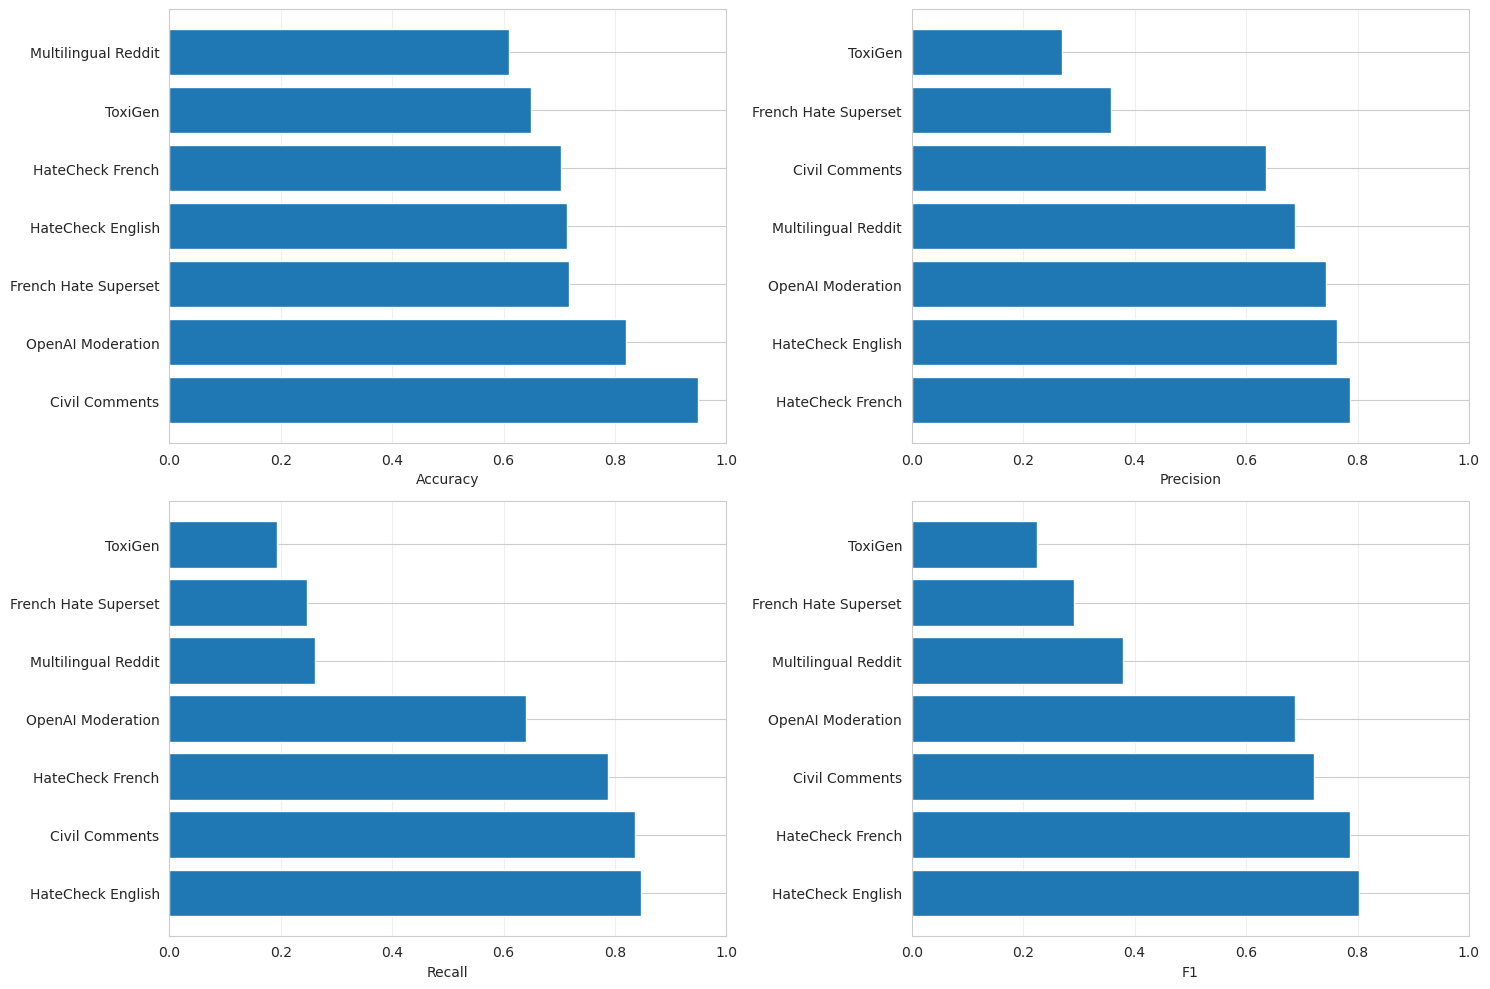

In [16]:
if all_metrics:
    # Convert to dict format for plotting
    metrics_dict_list = [
        {
            'dataset_name': m.dataset_name,
            'accuracy': m.accuracy,
            'precision': m.precision,
            'recall': m.recall,
            'f1': m.f1
        }
        for m in all_metrics
    ]
    
    plot_metrics_comparison(metrics_dict_list)

### 7.4 Additional Visualizations

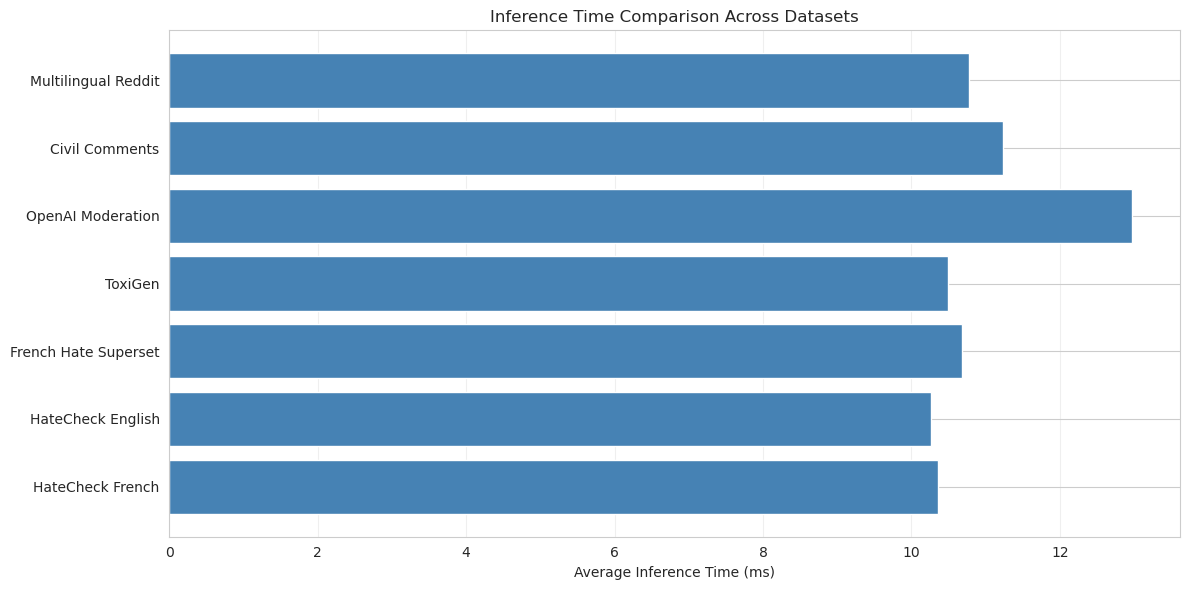

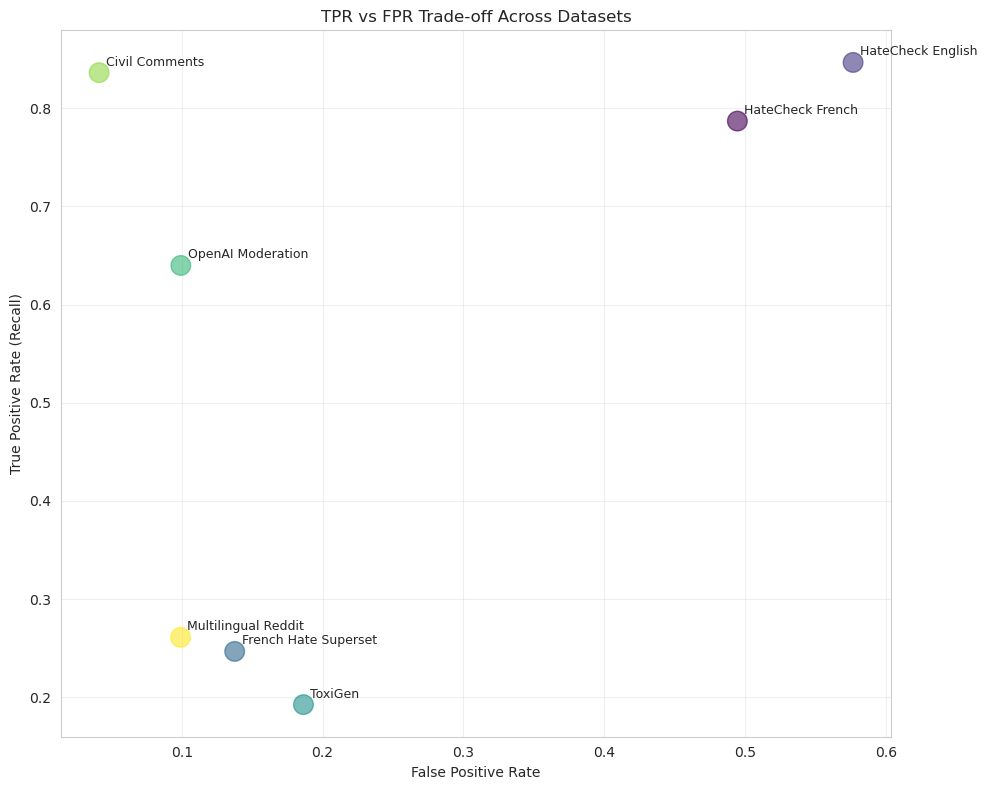

In [17]:
if all_metrics:
    # Inference time comparison
    plt.figure(figsize=(12, 6))
    datasets = [m.dataset_name for m in all_metrics]
    times = [m.avg_inference_time_ms for m in all_metrics]
    
    plt.barh(datasets, times, color='steelblue')
    plt.xlabel('Average Inference Time (ms)')
    plt.title('Inference Time Comparison Across Datasets')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # TPR vs FPR scatter
    plt.figure(figsize=(10, 8))
    tpr = [m.true_positive_rate for m in all_metrics]
    fpr = [m.false_positive_rate for m in all_metrics]
    
    plt.scatter(fpr, tpr, s=200, alpha=0.6, c=range(len(all_metrics)), cmap='viridis')
    
    for i, m in enumerate(all_metrics):
        plt.annotate(m.dataset_name, (fpr[i], tpr[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('TPR vs FPR Trade-off Across Datasets')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 7.5 Export Complete Results

In [18]:
if all_info and all_metrics:
    # Create comprehensive JSON export
    export_data = {
        'model': 'Detoxify Multilingual',
        'toxicity_threshold': TOXICITY_THRESHOLD,
        'device': DEVICE,
        'date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'datasets': [
            {
                'name': info.name,
                'size_mb': info.size_mb,
                'num_samples': info.num_samples,
                'num_safe': info.num_safe,
                'num_unsafe': info.num_unsafe,
                'language': info.language,
                'label_distribution': info.label_distribution
            }
            for info in all_info
        ],
        'performance': [
            {
                'dataset_name': m.dataset_name,
                'accuracy': m.accuracy,
                'precision': m.precision,
                'recall': m.recall,
                'f1': m.f1,
                'avg_inference_time_ms': m.avg_inference_time_ms,
                'gpu_memory_mb': m.gpu_memory_mb,
                'errors': m.errors,
                'confusion_matrix': {
                    'tp': m.true_positives,
                    'fp': m.false_positives,
                    'tn': m.true_negatives,
                    'fn': m.false_negatives,
                    'tpr': m.true_positive_rate,
                    'fpr': m.false_positive_rate,
                    'tnr': m.true_negative_rate,
                    'fnr': m.false_negative_rate
                }
            }
            for m in all_metrics
        ]
    }
    
    # Save JSON
    json_path = OUTPUT_DIR / "complete_evaluation_results.json"
    with open(json_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"\n✅ Complete results saved to: {json_path}")
    print(f"\n📁 All outputs saved to: {OUTPUT_DIR}")
    print("\nGenerated files:")
    print("  - dataset_overview.csv")
    print("  - performance_summary.csv")
    print("  - confusion_matrix_summary.csv")
    print("  - complete_evaluation_results.json")


✅ Complete results saved to: /home/sural/code/results/dataset_exploration/complete_evaluation_results.json

📁 All outputs saved to: /home/sural/code/results/dataset_exploration

Generated files:
  - dataset_overview.csv
  - performance_summary.csv
  - confusion_matrix_summary.csv
  - complete_evaluation_results.json
